# 02 — Vocabulario (Fase 2)

Prueba interactiva de `src/vocabulary.py`. Se valida:

1. El conteo de frecuencias **por streaming** sobre el corpus comprimido.
2. La construcción del vocabulario: top-N palabras + `<UNK>`.
3. La cobertura de tokens (cuánto del corpus queda fuera del vocabulario) para
   la config base y para toda el `vocab_size`.
4. El subsampling de palabras frecuentes (Mikolov et al., 2013).
5. La serialización a `data/processed/{config_name}/vocab.json`.

El notebook tiene dos partes: el análisis exploratorio corre sobre una **muestra**
(rápido, iterativo), y al final se carga el vocabulario **definitivo** construido
sobre el corpus completo desde la línea de comandos.

In [2]:
import sys
import time
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from src.config import corpus_path, load_config, vocab_path
from src.vocabulary import (
    Vocabulary,
    build_vocabulary,
    count_word_frequencies,
    subsample,
)

CONFIG = load_config("configs/base.yaml")
CORPUS = corpus_path(CONFIG)
TOK = CONFIG["tokenizer"]

print("config      :", CONFIG["name"])
print("vocab_size  :", CONFIG["vocab_size"])
print("min_count   :", CONFIG["min_count"])
print("subsampling :", CONFIG["subsampling_threshold"])
print("corpus      :", CORPUS.name, "| existe:", CORPUS.exists())

config      : base_5k_50_2
vocab_size  : 5000
min_count   : 5
subsampling : 1e-05
corpus      : sbwce.clean.txt.bz2 | existe: True


## 1. Conteo de frecuencias sobre una muestra

`count_word_frequencies` recorre el corpus con los generadores de la Fase 1 y
acumula un `Counter`. Separarlo de la construcción del vocabulario permite
derivar después varios `vocab_size` / `min_count` del **mismo** conteo, sin
volver a leer los 3 GB.

> NOTA: `limit=N` toma las **primeras** N oraciones, y el SBWC arranca con un bloque
> de texto religioso. La muestra está sesgada temáticamente. Sirve para validar
> el código y ver las tendencias.

In [3]:
N_MUESTRA = 500_000

t0 = time.time()
counts, total_tokens, n_sentences = count_word_frequencies(
    CORPUS, limit=N_MUESTRA, **TOK
)
elapsed = time.time() - t0

print(f"oraciones        : {n_sentences:,}")
print(f"tokens           : {total_tokens:,}")
print(f"tipos distintos  : {len(counts):,}")
print(f"segundos         : {elapsed:,.1f}  ({n_sentences / elapsed:,.0f} oraciones/s)")
print(f"hapax (freq == 1): {sum(1 for c in counts.values() if c == 1):,}")

oraciones        : 500,000
tokens           : 13,777,016
tipos distintos  : 171,562
segundos         : 22.4  (22,285 oraciones/s)
hapax (freq == 1): 89,407


In [4]:
counts

Counter({'de': 1203398,
         'la': 640785,
         'en': 413922,
         '<NUM>': 402085,
         'el': 382745,
         'y': 348874,
         'que': 322762,
         'a': 304174,
         'los': 303236,
         'las': 231120,
         'del': 224432,
         'se': 157451,
         'por': 138570,
         'para': 112445,
         'un': 112125,
         'una': 107950,
         'con': 98582,
         'no': 84995,
         'al': 78167,
         'comisión': 65222,
         'es': 59808,
         'sobre': 57435,
         'su': 50650,
         'o': 47296,
         'como': 45875,
         'lo': 40950,
         'consejo': 38929,
         'ha': 38515,
         'más': 37549,
         'este': 35607,
         'estados': 29100,
         'entre': 28196,
         'europea': 26825,
         'miembros': 26793,
         'esta': 25007,
         'sus': 24929,
         'comunidad': 24096,
         'países': 23087,
         'cee': 22146,
         'europeo': 21793,
         'también': 21559,
         

## 2. Vocabulario de la configuración base

`Vocabulary.from_counts` selecciona el top-N y coloca `<UNK>` en el índice 0.
`vocab_size` es el tamaño **total** incluyendo `<UNK>`, así que coincide con el
número de filas que tendrá la matriz de embeddings.

In [5]:
vocab = Vocabulary.from_counts(
    counts, total_tokens, CONFIG["vocab_size"], min_count=CONFIG["min_count"]
)
print(vocab)
print()
print(f"tamaño final del vocabulario : {len(vocab):,}")
print(f"  (índice 0 = {vocab.itos[0]!r}, índices 1..{len(vocab) - 1} = palabras)")

Vocabulary(size=5000, total_tokens=13,777,016, coverage=0.9042, min_count=5)

tamaño final del vocabulario : 5,000
  (índice 0 = '<UNK>', índices 1..4999 = palabras)


In [6]:
print(f"{'#':>4}  {'palabra':<14} {'frecuencia':>12}  {'% del corpus':>13}")
print("-" * 50)
for rank, (word, count) in enumerate(vocab.most_common(20), start=1):
    print(f"{rank:>4}. {word:<14} {count:>12,}  {count / total_tokens:>12.3%}")

   #  palabra          frecuencia   % del corpus
--------------------------------------------------
   1. de                1,203,398        8.735%
   2. la                  640,785        4.651%
   3. en                  413,922        3.004%
   4. <NUM>               402,085        2.919%
   5. el                  382,745        2.778%
   6. y                   348,874        2.532%
   7. que                 322,762        2.343%
   8. a                   304,174        2.208%
   9. los                 303,236        2.201%
  10. las                 231,120        1.678%
  11. del                 224,432        1.629%
  12. se                  157,451        1.143%
  13. por                 138,570        1.006%
  14. para                112,445        0.816%
  15. un                  112,125        0.814%
  16. una                 107,950        0.784%
  17. con                  98,582        0.716%
  18. no                   84,995        0.617%
  19. al                   78,167   

### Cobertura vs `<UNK>`

La métrica clave de la fase: qué porcentaje de las ocurrencias del corpus queda
representado por palabras reales y cuánto cae en `<UNK>`.

In [7]:
print(f"tokens totales      : {vocab.total_tokens:,}")
print(f"tokens cubiertos    : {vocab.total_tokens - vocab.unk_count:,}  ({vocab.coverage:.2%})")
print(f"tokens en <UNK>     : {vocab.unk_count:,}  ({1 - vocab.coverage:.2%})")
print()
print(f"tipos en el corpus  : {len(counts):,}")
print(f"tipos en el vocab   : {len(vocab) - 1:,}  ({(len(vocab) - 1) / len(counts):.2%} de los tipos)")
print()
print("Es la asimetría típica de Zipf: una fracción mínima de los tipos")
print("cubre la enorme mayoría de las ocurrencias.")

tokens totales      : 13,777,016
tokens cubiertos    : 12,457,752  (90.42%)
tokens en <UNK>     : 1,319,264  (9.58%)

tipos en el corpus  : 171,562
tipos en el vocab   : 4,999  (2.91% de los tipos)

Es la asimetría típica de Zipf: una fracción mínima de los tipos
cubre la enorme mayoría de las ocurrencias.


## 3. Ley de Zipf

Frecuencia vs rango en escala log-log. Una recta confirma la distribución
zipfiana y explica por qué un vocabulario chico cubre tanto texto.

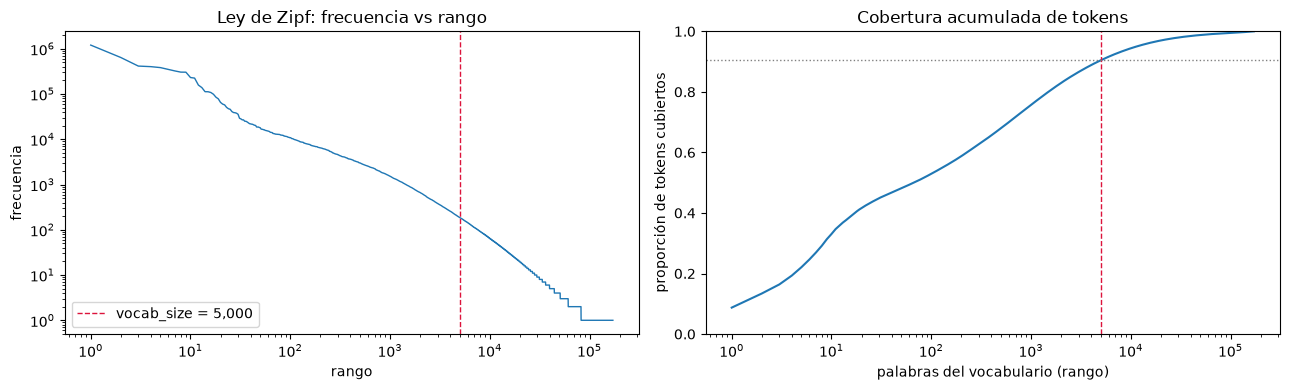

In [8]:
frecuencias = sorted(counts.values(), reverse=True)
rangos = range(1, len(frecuencias) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].loglog(rangos, frecuencias, lw=1)
axes[0].axvline(CONFIG["vocab_size"], ls="--", c="crimson", lw=1,
                label=f"vocab_size = {CONFIG['vocab_size']:,}")
axes[0].set_title("Ley de Zipf: frecuencia vs rango")
axes[0].set_xlabel("rango")
axes[0].set_ylabel("frecuencia")
axes[0].legend()

acumulado = 0
cobertura_acum = []
for f in frecuencias:
    acumulado += f
    cobertura_acum.append(acumulado / total_tokens)

axes[1].semilogx(rangos, cobertura_acum, lw=1.5)
axes[1].axvline(CONFIG["vocab_size"], ls="--", c="crimson", lw=1)
axes[1].axhline(vocab.coverage, ls=":", c="gray", lw=1)
axes[1].set_title("Cobertura acumulada de tokens")
axes[1].set_xlabel("palabras del vocabulario (rango)")
axes[1].set_ylabel("proporción de tokens cubiertos")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Ley de Zipf (Frecuencia vs. Rango en log-log)**
* Cumplimiento de la Ley de Zipf: Al usar una escala doble logarítmica (loglog), la relación decreciente casi lineal demuestra que el corpus sigue la Ley de Zipf. Un número muy reducido de palabras (las de menor rango, como preposiciones, artículos y palabras clave) concentra la gran mayoría de las apariciones (frecuencias superiores a $10^5$ ó $10^6$).
* Límite de vocab_size (5,000): La línea roja vertical señala el punto de corte elegido para el vocabulario. Todo lo que está a la izquierda se conserva como token conocido, mientras que las palabras a la derecha de la línea roja pertenecen a la cola larga y quedarían representadas como tokens desconocidos (´´<unk>´´) o divididas en subpalabras.

**Cobertura acumulada de tokens (Eje X logarítmico)**
* Rendimiento de los términos más frecuentes: Un número pequeño de palabras cubre una gran parte del texto. Por ejemplo, apenas las primeras ~10 a 100 palabras ya cubren entre el 40% y 50% de todos los tokens presentes en el corpus.
* Cobertura con el tamaño seleccionado (vocab_size = 5,000): La intersección de la línea roja vertical con la curva (marcada también por la línea punteada gris horizontal) indica que con solo 5,000 palabras se alcanza aproximadamente un 90% cobertura total del texto.
* Rendimientos decrecientes: Para pasar del 90% al 100% de cobertura se requerirían decenas de miles de palabras adicionales (pasar de $5 \times 10^3$ a más de $10^5$ palabras), lo cual aumentaría enormemente la dimensión del modelo con un beneficio marginal muy bajo.

## 4. Cobertura para las variantes de `vocab_size`

La especificación contempla escalar a 5k / 10k / 15k / 20k. Como el conteo ya
está en memoria, se puede evaluar cada tamaño sin volver a recorrer el corpus:
esto dice cuánto se gana realmente al agrandar el vocabulario.

In [9]:
GRILLA = [5_000, 10_000, 15_000, 20_000]

print(f"{'vocab_size':>11}  {'tamaño real':>12}  {'cobertura':>10}  {'<UNK>':>8}")
print("-" * 48)
resultados = []
for vs in GRILLA:
    v = Vocabulary.from_counts(counts, total_tokens, vs, min_count=CONFIG["min_count"])
    resultados.append((vs, len(v), v.coverage))
    print(f"{vs:>11,}  {len(v):>12,}  {v.coverage:>9.2%}  {1 - v.coverage:>7.2%}")

print()
print("El tamaño real puede quedar por debajo de vocab_size si no hay suficientes")
print(f"palabras con frecuencia >= min_count ({CONFIG['min_count']}) en la muestra.")

 vocab_size   tamaño real   cobertura     <UNK>
------------------------------------------------
      5,000         5,000     90.42%    9.58%
     10,000        10,000     94.39%    5.61%
     15,000        15,000     96.06%    3.94%
     20,000        20,000     96.98%    3.02%

El tamaño real puede quedar por debajo de vocab_size si no hay suficientes
palabras con frecuencia >= min_count (5) en la muestra.


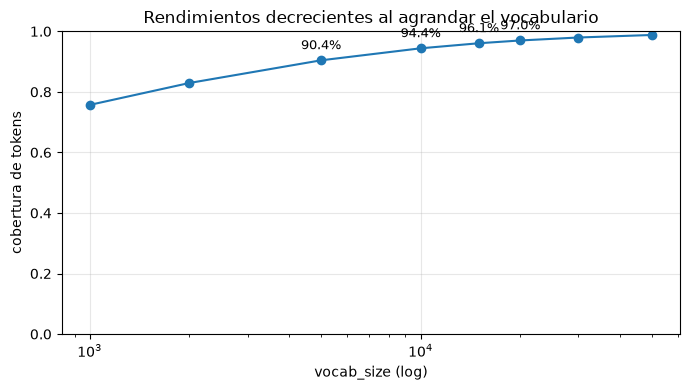

In [10]:
barrido = [1_000, 2_000, 5_000, 10_000, 15_000, 20_000, 30_000, 50_000]
coberturas = [
    Vocabulary.from_counts(counts, total_tokens, vs, min_count=1).coverage
    for vs in barrido
]

plt.figure(figsize=(7, 4))
plt.plot(barrido, coberturas, "o-")
for vs, cob in zip(barrido, coberturas):
    if vs in GRILLA:
        plt.annotate(f"{cob:.1%}", (vs, cob), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)
plt.xscale("log")
plt.ylim(0, 1)
plt.xlabel("vocab_size (log)")
plt.ylabel("cobertura de tokens")
plt.title("Rendimientos decrecientes al agrandar el vocabulario")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Efecto de `min_count`

`min_count` filtra las palabras demasiado raras antes de tomar el top-N. Con un
`vocab_size` chico casi no cambia nada (esas palabras no entrarían igual). Apenas empieza a tenener importancia cuando el vocabulario es grande.

In [11]:
print(f"{'min_count':>10}  {'candidatos':>12}  {'tamaño 5k':>10}  {'tamaño 20k':>11}")
print("-" * 50)
for mc in (1, 5, 10, 50, 100):
    candidatos = sum(1 for c in counts.values() if c >= mc)
    v5 = Vocabulary.from_counts(counts, total_tokens, 5_000, min_count=mc)
    v20 = Vocabulary.from_counts(counts, total_tokens, 20_000, min_count=mc)
    print(f"{mc:>10}  {candidatos:>12,}  {len(v5):>10,}  {len(v20):>11,}")

 min_count    candidatos   tamaño 5k   tamaño 20k
--------------------------------------------------
         1       171,562       5,000       20,000
         5        44,316       5,000       20,000
        10        29,604       5,000       20,000
        50        11,781       5,000       11,782
       100         7,615       5,000        7,616


## 6. Subsampling de palabras frecuentes

`subsample` implementa la fórmula de Mikolov et al. (2013):

$$P_{keep}(w) = \min\left(1, \sqrt{\frac{t}{f(w)}}\right)$$

donde $f(w)$ es la frecuencia relativa de la palabra y $t$ el umbral
(`subsampling_threshold`). Las palabras muy frecuentes se descartan casi siempre,
las que están por debajo del umbral se conservan enteras.

In [12]:
T = CONFIG["subsampling_threshold"]
keep = vocab.keep_probabilities(T)

print(f"umbral t = {T}\n")
print(f"{'palabra':<14} {'rango':>6} {'frecuencia':>12} {'f(w)':>10} {'P(keep)':>9}")
print("-" * 56)
muestras = [0, 1, 2, 3, 5, 10, 50, 100, 500, 1_000, 2_000, len(vocab) - 1]
for i in muestras:
    f = vocab.counts[i] / vocab.total_tokens
    print(f"{vocab.itos[i]:<14} {i:>6} {vocab.counts[i]:>12,} {f:>10.5f} {keep[i]:>9.4f}")

umbral t = 1e-05

palabra         rango   frecuencia       f(w)   P(keep)
--------------------------------------------------------
<UNK>               0    1,319,264    0.09576    0.0102
de                  1    1,203,398    0.08735    0.0107
la                  2      640,785    0.04651    0.0147
en                  3      413,922    0.03004    0.0182
el                  5      382,745    0.02778    0.0190
las                10      231,120    0.01678    0.0244
reglamento         50       17,966    0.00130    0.0876
debe              100       10,825    0.00079    0.1128
existe            500        2,999    0.00022    0.2143
ministerio       1000        1,524    0.00011    0.3007
considerado      2000          667    0.00005    0.4545
oponen           4999          186    0.00001    0.8606


In [13]:
# Cuánto se achica el corpus efectivo al aplicar subsampling
esperado = sum(c * p for c, p in zip(vocab.counts, keep))
print(f"tokens antes del subsampling : {vocab.total_tokens:,}")
print(f"tokens esperados después     : {esperado:,.0f}")
print(f"reducción                    : {1 - esperado / vocab.total_tokens:.1%}")
print()
print("Menos tokens de entrenamiento, pero mucho mejor repartidos: las palabras")
print("de contenido dejan de competir con 'de', 'la' y 'que' en cada ventana.")

tokens antes del subsampling : 13,777,016
tokens esperados después     : 1,868,967
reducción                    : 86.4%

Menos tokens de entrenamiento, pero mucho mejor repartidos: las palabras
de contenido dejan de competir con 'de', 'la' y 'que' en cada ventana.


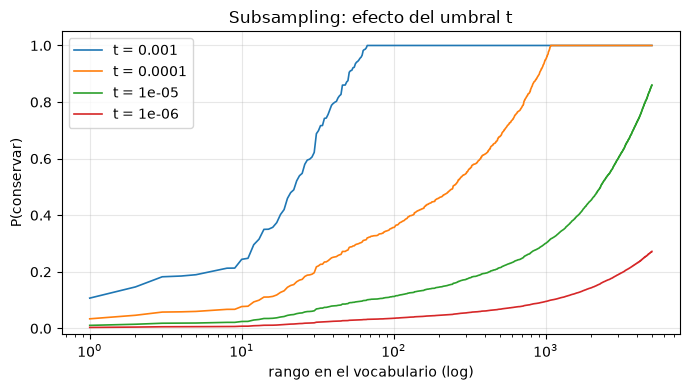

In [14]:
plt.figure(figsize=(7, 4))
for t in (1e-3, 1e-4, 1e-5, 1e-6):
    k = vocab.keep_probabilities(t)
    plt.plot(range(1, len(vocab)), k[1:], lw=1.2, label=f"t = {t:g}")
plt.axvline(1, alpha=0)
plt.xscale("log")
plt.ylim(-0.02, 1.05)
plt.xlabel("rango en el vocabulario (log)")
plt.ylabel("P(conservar)")
plt.title("Subsampling: efecto del umbral t")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Comportamiento según la frecuencia**
* **Palabras más frecuentes (Rango 1 a 10):** Tienen una probabilidad de conservación $P(\text{conservar})$ extremadamente baja (entre 0 y 0.2). Esto demuestra cómo palabras como "de", "la" o "que" son descartadas de manera masiva para evitar que dominen las ventanas de contexto.
* **Umbral permisisvo ($t = 0.001$, azul):** Comienza a conservar el $100\%$ de las palabras a partir de rangos muy tempranos (~70-80 en el vocabulario). Es un filtrado suave que mantiene más tokens.  
* **Umbrales estándar ($t = 0.0001$, naranja):** Es el valor típico usado en Word2Vec. Mantiene probabilidades muy bajas para las palabras top, pero alcanza la conservación total ($P=1.0$) alrededor del rango ~1,000. 
* **Umbrales agresivos ($t = 1\text{e-}5$ verde, $t = 1\text{e-}6$ rojo):** Filtran drásticamente gran parte del vocabulario. Incluso para palabras situadas en el rango 1,000–5,000, la probabilidad de mantenerlas sigue siendo inferior al $30\%$–$85\%$.  

## 7. Validación de la poda `max_types`

Sobre el corpus completo el `Counter` puede llegar a varios millones de tipos.
`max_types` acota esa memoria descartando periódicamente los tipos menos
frecuentes vistos hasta el momento, lo que vuelve **aproximados** los conteos de
la cola larga. Acá se mide cuánto afecta eso al vocabulario que realmente
importa, comparando contra el conteo exacto.

In [15]:
N_PODA = 300_000
exacto, total_exacto, _ = count_word_frequencies(CORPUS, limit=N_PODA, **TOK)
v_exacto = Vocabulary.from_counts(exacto, total_exacto, 5_000, min_count=5)

print(f"conteo exacto: {len(exacto):,} tipos distintos en {N_PODA:,} oraciones\n")
print(f"{'max_types':>10}  {'tipos':>8}  {'top-100':>8}  {'palabras en común':>18}  {'cobertura':>10}")
print("-" * 64)
print(f"{'(exacto)':>10}  {len(exacto):>8,}  {'—':>8}  {'—':>18}  {v_exacto.coverage:>10.4f}")

for mt in (50_000, 20_000, 10_000):
    podado, total_podado, _ = count_word_frequencies(
        CORPUS, limit=N_PODA, max_types=mt, **TOK
    )
    v_podado = Vocabulary.from_counts(podado, total_podado, 5_000, min_count=5)
    igual_top = v_exacto.itos[:100] == v_podado.itos[:100]
    comunes = len(set(v_exacto.itos) & set(v_podado.itos))
    print(f"{mt:>10,}  {len(podado):>8,}  {str(igual_top):>8}  "
          f"{comunes:>13,}/{len(v_exacto):<4,}  {v_podado.coverage:>10.4f}")

conteo exacto: 125,979 tipos distintos en 300,000 oraciones

 max_types     tipos   top-100   palabras en común   cobertura
----------------------------------------------------------------
  (exacto)   125,979         —                   —      0.9055
    50,000    49,225      True          5,000/5,000      0.9055
    20,000    15,880      True          4,950/5,000      0.9051
    10,000     9,850      True          3,951/5,000      0.8816


La regla que sale de ahí: mientras `max_types` sea holgadamente mayor que
`vocab_size` (unas 4-10 veces o más), el top-N y la cobertura quedan
prácticamente intactos —solo se reordenan empates en la cola—. La degradación
aparece recién cuando la cota se acerca al tamaño del vocabulario. Con
`--max-types 3000000` para un vocabulario de 5.000 el margen es enorme.

## 8. Vocabulario definitivo (corpus completo)

El vocabulario que consumirán las fases siguientes se construye sobre el corpus
entero desde la línea de comandos (un pase completo, del orden de decenas de
minutos):

```bash
python -m src.vocabulary --config configs/base.yaml --max-types 3000000
```

`--max-types` acota los tipos distintos que se mantienen en memoria podando la
cola larga; no afecta a las palabras frecuentes, que son las únicas que entran
al vocabulario.

In [16]:
DESTINO = vocab_path(CONFIG)
print("archivo:", DESTINO)

if DESTINO.exists():
    definitivo = Vocabulary.load(DESTINO)
    print(f"tamaño en disco: {DESTINO.stat().st_size / 1024:,.1f} KB\n")
    print(definitivo)
    print()
    print(f"tokens totales   : {definitivo.total_tokens:,}")
    print(f"tokens en <UNK>  : {definitivo.unk_count:,}  ({1 - definitivo.coverage:.2%})")
    print(f"cobertura        : {definitivo.coverage:.2%}")
    print()
    print(f"{'#':>4}  {'palabra':<14} {'frecuencia':>14}  {'% del corpus':>13}")
    print("-" * 52)
    for rank, (word, count) in enumerate(definitivo.most_common(20), start=1):
        print(f"{rank:>4}. {word:<14} {count:>14,}  {count / definitivo.total_tokens:>12.3%}")
else:
    definitivo = None
    print("Todavía no existe: correr el comando de arriba para generarlo.")

archivo: C:\Users\Carlo\Documents\Maestria\Proyecto_T\projects_claude\proyecto_cbow\data\processed\base_5k_50_2\vocab.json
tamaño en disco: 220.2 KB

Vocabulary(size=5000, total_tokens=2,028,209,650, coverage=0.8326, min_count=5)

tokens totales   : 2,028,209,650
tokens en <UNK>  : 339,595,345  (16.74%)
cobertura        : 83.26%

   #  palabra            frecuencia   % del corpus
----------------------------------------------------
   1. de                151,730,127        7.481%
   2. la                 81,271,721        4.007%
   3. en                 57,489,474        2.834%
   4. el                 57,311,995        2.826%
   5. y                  52,333,053        2.580%
   6. <NUM>              51,748,553        2.551%
   7. que                50,290,880        2.480%
   8. a                  43,608,452        2.150%
   9. los                32,661,832        1.610%
  10. del                27,081,384        1.335%
  11. las                23,913,188        1.179%
  12. se      

### Comparación muestra vs corpus completo

Cuánto se parece el vocabulario derivado de las primeras 500k oraciones al que
sale del corpus entero. Es la medida directa del sesgo de usar `limit`.

In [17]:
if definitivo is not None:
    en_ambos = set(vocab.itos) & set(definitivo.itos)
    print(f"palabras en común : {len(en_ambos):,} de {len(definitivo):,} "
          f"({len(en_ambos) / len(definitivo):.1%})")
    print(f"cobertura muestra : {vocab.coverage:.2%}")
    print(f"cobertura completo: {definitivo.coverage:.2%}")
    print()
    solo_muestra = [w for w in vocab.itos[1:] if w not in definitivo.stoi][:15]
    print("Solo en la muestra (sesgo temático del comienzo del corpus):")
    print(" ", ", ".join(solo_muestra) if solo_muestra else "(ninguna)")
else:
    print("Requiere el vocabulario completo.")

palabras en común : 3,463 de 5,000 (69.3%)
cobertura muestra : 90.42%
cobertura completo: 83.26%

Solo en la muestra (sesgo temático del comienzo del corpus):
  alá, ppe, pe, ecu, usd, nl, bei, po, feder, maastricht, pse, interlocutores, paro, convergencia, medioambientales


## 9. Serialización

`vocab.json` guarda `itos` (índice→palabra), `stoi` (palabra→índice) y los
conteos. `stoi` es redundante —se puede reconstruir desde `itos`— pero se
almacena para que el archivo sea directamente usable desde fuera de este código.

In [18]:
prueba = ROOT / "data" / "processed" / "_roundtrip" / "vocab.json"
vocab.save(prueba)
recargado = Vocabulary.load(prueba)

print("itos idéntico          :", recargado.itos == vocab.itos)
print("stoi idéntico          :", recargado.stoi == vocab.stoi)
print("counts idéntico        :", recargado.counts == vocab.counts)
print("total_tokens idéntico  :", recargado.total_tokens == vocab.total_tokens)
print("cobertura idéntica     :", recargado.coverage == vocab.coverage)

import json as _json
claves = list(_json.loads(prueba.read_text(encoding="utf-8")).keys())
print("\nclaves del JSON:", claves)

import shutil
shutil.rmtree(prueba.parent)

itos idéntico          : True
stoi idéntico          : True
counts idéntico        : True
total_tokens idéntico  : True
cobertura idéntica     : True

claves del JSON: ['unk_token', 'min_count', 'total_tokens', 'vocab_size', 'coverage', 'itos', 'stoi', 'counts']


In [ ]:

oracion = "el gobierno anunció una inversión de 500 millones en xyzqwk"
from src.corpus import tokenize

tokens = tokenize(oracion, **TOK)
indices = vocab.encode(tokens)

print("tokens :", tokens)
print("índices:", indices)
print("vuelta :", vocab.decode(indices))
print()
print("sin OOV:", vocab.decode(vocab.encode(tokens, drop_unknown=True)))

tokens : ['el', 'gobierno', 'anunció', 'una', 'inversión', 'de', '<NUM>', 'millones', 'en', 'xyzqwk']
índices: [5, 240, 4914, 16, 516, 1, 4, 63, 3, 0]
vuelta : ['el', 'gobierno', 'anunció', 'una', 'inversión', 'de', '<NUM>', 'millones', 'en', '<UNK>']

sin OOV: ['el', 'gobierno', 'anunció', 'una', 'inversión', 'de', '<NUM>', 'millones', 'en']


## Conclusiones de la Fase 2

- El conteo de frecuencias funciona por streaming; `max_types` acota la memoria
  para el corpus completo sin afectar a las palabras que entran al vocabulario.
- `Vocabulary` encapsula el mapeo palabra↔índice, los conteos y la cobertura, y
  se serializa/recarga sin pérdida.
- Separar el conteo de la selección del top-N permite comparar toda la grilla de
  `vocab_size` con un solo pase por el corpus.
- El subsampling de Mikolov está implementado y verificado sobre los umbrales
  típicos.

**Siguiente paso:** Fase 3 — `src/dataset.py` (generación por streaming de pares
contexto-target y `CBOWDataset` para el `DataLoader`).